In [1]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.getOrCreate()

In [2]:
def readMariaDB(table_name, database):
    dfMaria = spark.read \
            .format("jdbc") \
            .option("driver", "org.mariadb.jdbc.Driver") \
            .option("url", f"jdbc:mysql://localhost:3306/{database}?permitMysqlScheme") \
            .option("dbtable", f"{table_name}") \
            .option("user", "root") \
            .option("password", "Thanhdan@123") \
            .load()

    return dfMaria

In [3]:
categories = readMariaDB("categories", "retails")
customers = readMariaDB("customers", "retails")
departments = readMariaDB("departments", "retails")
order_items = readMariaDB("order_items", "retails")
orders = readMariaDB("orders", "retails")
products = readMariaDB("products", "retails")

In [4]:
categories.createOrReplaceTempView("categories")
customers.createOrReplaceTempView("customers")
departments.createOrReplaceTempView("departments")
order_items.createOrReplaceTempView("order_items")
orders.createOrReplaceTempView("orders")
products.createOrReplaceTempView("products")

In [5]:
customers.show(1)

+-----------+--------------+--------------+--------------+-----------------+------------------+-------------+--------------+----------------+
|customer_id|customer_fname|customer_lname|customer_email|customer_password|   customer_street|customer_city|customer_state|customer_zipcode|
+-----------+--------------+--------------+--------------+-----------------+------------------+-------------+--------------+----------------+
|          1|       Richard|     Hernandez|     XXXXXXXXX|        XXXXXXXXX|6303 Heather Plaza|  Brownsville|            TX|           78521|
+-----------+--------------+--------------+--------------+-----------------+------------------+-------------+--------------+----------------+
only showing top 1 row


In [6]:
orders.show(1)

+--------+-------------------+-----------------+------------+
|order_id|         order_date|order_customer_id|order_status|
+--------+-------------------+-----------------+------------+
|       1|2013-07-25 00:00:00|            11599|      CLOSED|
+--------+-------------------+-----------------+------------+
only showing top 1 row


# 1. Get the order count per customer for January 2024.
* Tables - orders and customers
* Data should be sorted in descending order by count and ascending order by customer ID.
* Output should contain customer_id, customer_first_name, customer_last_name and customer_order_count.

In [7]:
spark.sql("""
select c.customer_id, c.customer_fname as customer_first_name, c.customer_lname as customer_last_name, count(c.customer_id) as customer_order_count
from orders o
left join customers c on o.order_customer_id = c.customer_id
group by c.customer_id, customer_first_name, customer_last_name
order by customer_order_count desc, c.customer_id
""").show()

+-----------+-------------------+------------------+--------------------+
|customer_id|customer_first_name|customer_last_name|customer_order_count|
+-----------+-------------------+------------------+--------------------+
|        569|               Mary|              Frye|                  16|
|       5897|               Mary|           Griffin|                  16|
|       6316|               Kyle|             Smith|                  16|
|      12431|               Mary|              Rios|                  16|
|        221|               Mary|               Cox|                  15|
|       4320|             Jordan|            Taylor|                  15|
|       5283|              Jacob|          Guerrero|                  15|
|       5624|               Mary|              Mata|                  15|
|       5654|              Jerry|             Smith|                  15|
|      12284|               Mary|             Smith|                  15|
|        791|               Mary|     

# 2. Get the customer details of those who have not placed any orders in January 2024.
* Tables - orders and customers
* Data should be sorted in ascending order by customer_id
* Output should contain all the fields from the customers
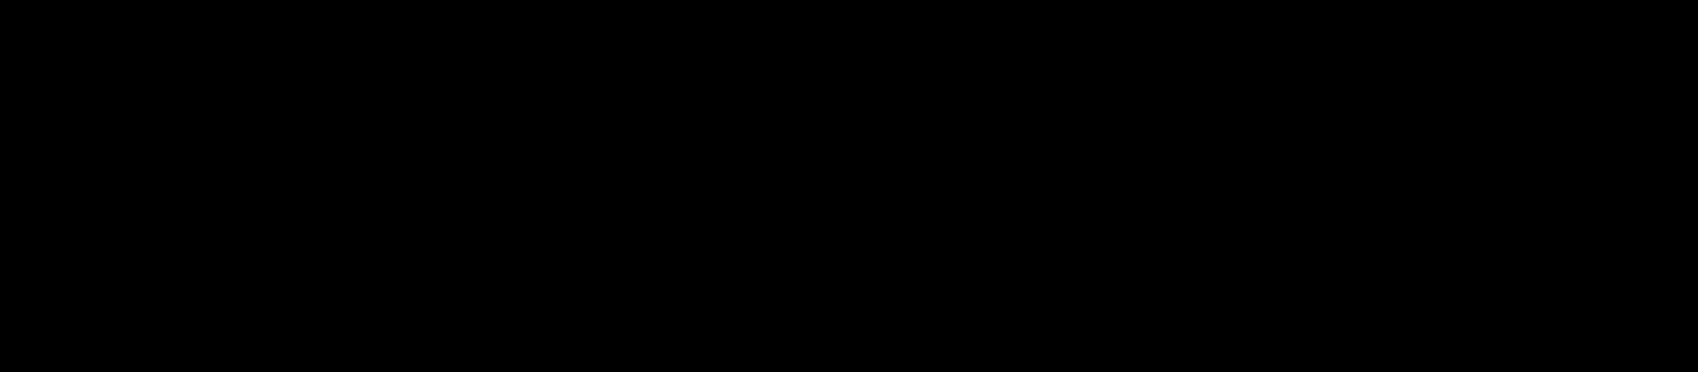

In [8]:
spark.sql("""
select c.*
from customers c
left join (
    select distinct order_customer_id
    from orders
    where order_date between "2024-01-01" and "2024-01-31"
) o on c.customer_id = o.order_customer_id
where o.order_customer_id is null
order by c.customer_id
""").show()

+-----------+--------------+--------------+--------------+-----------------+--------------------+-------------+--------------+----------------+
|customer_id|customer_fname|customer_lname|customer_email|customer_password|     customer_street|customer_city|customer_state|customer_zipcode|
+-----------+--------------+--------------+--------------+-----------------+--------------------+-------------+--------------+----------------+
|          1|       Richard|     Hernandez|     XXXXXXXXX|        XXXXXXXXX|  6303 Heather Plaza|  Brownsville|            TX|           78521|
|          2|          Mary|       Barrett|     XXXXXXXXX|        XXXXXXXXX|9526 Noble Embers...|    Littleton|            CO|           80126|
|          3|           Ann|         Smith|     XXXXXXXXX|        XXXXXXXXX|3422 Blue Pioneer...|       Caguas|            PR|           00725|
|          4|          Mary|         Jones|     XXXXXXXXX|        XXXXXXXXX|  8324 Little Common|   San Marcos|            CA|          

# 3. Get the revenue generated by each customer for January 2024
* Tables - orders, order_items, and customers
* Data should be sorted in descending order by revenue and then ascending order by
customer_id.
* Output should contain customer_id, customer_first_name, customer_last_name,
customer_revenue.
* If the customer places no orders, then the corresponding revenue for a given customer
should be 0.
* Consider only COMPLETE and CLOSED orders

In [9]:
spark.sql("""
select c.customer_id, c.customer_fname as customer_first_name, c.customer_lname as customer_last_name,
       coalesce(round(sum(oi.order_item_subtotal), 2), 0) as customer_revenue
from customers c
left join (
    select order_id, order_customer_id
    from orders
    where (order_date between "2014-01-01" and "2014-01-31")
      and (order_status in ("COMPLETE","CLOSED"))) o on c.customer_id = o.order_customer_id
left join order_items oi on o.order_id = oi.order_item_order_id
group by c.customer_id, customer_first_name, customer_last_name
order by customer_revenue desc, c.customer_id
""").show()

+-----------+-------------------+------------------+----------------+
|customer_id|customer_first_name|customer_last_name|customer_revenue|
+-----------+-------------------+------------------+----------------+
|       2555|               Mary|              Long|         2954.63|
|       3465|               Mary|           Gardner|         2929.74|
|       3710|             Ashley|             Smith|         2739.82|
|       1780|              Larry|             Sharp|         2689.65|
|        986|          Catherine|           Hawkins|          2629.9|
|       9676|            Theresa|             Smith|         2599.84|
|       1847|               Mary|             Smith|         2589.87|
|      11901|               Mary|             Smith|         2469.87|
|       4618|             Andrea|             Smith|         2429.82|
|      10896|           Victoria|             Smith|         2419.78|
|       7982|             Ronald|              Hall|         2171.79|
|       5204|       

# 4. Get the revenue generated for each category for January 2024
* Tables - orders, order_items, products and categories
* Data should be sorted in ascending order by category_id.
* Output should contain all the fields from the category along with the revenue as
category_revenue.
* Consider only COMPLETE and CLOSED orders

In [10]:
spark.sql("""
select c.*, coalesce(round(sum(oi1.order_item_subtotal), 2), 0) as category_revenue
from categories c
left join (select product_id, product_category_id
           from products) p on c.category_id = p.product_category_id
left join (select oi.order_item_product_id, oi.order_item_subtotal
           from order_items oi
           inner join orders o on oi.order_item_order_id = o.order_id
           where (o.order_date between "2014-01-01" and "2014-01-31") and (o.order_status in ("COMPLETE","CLOSED")))
           oi1 on p.product_id = oi1.order_item_product_id
group by c.category_id, c.category_department_id, c.category_name
order by c.category_id
""").show()

+-----------+----------------------+-------------------+----------------+
|category_id|category_department_id|      category_name|category_revenue|
+-----------+----------------------+-------------------+----------------+
|          1|                     2|           Football|             0.0|
|          2|                     2|             Soccer|         1094.88|
|          3|                     2|Baseball & Softball|         3214.41|
|          4|                     2|         Basketball|         1299.98|
|          5|                     2|           Lacrosse|         1299.69|
|          6|                     2|   Tennis & Racquet|         1124.75|
|          7|                     2|             Hockey|          1433.0|
|          8|                     2|        More Sports|             0.0|
|          9|                     3|   Cardio Equipment|       133156.77|
|         10|                     3|  Strength Training|         3388.96|
|         11|                     3|Fi

# 5. Get the products for each department.
* a. Tables - departments, categories, products
* b. Data should be sorted in ascending order by department_id
* c. The output should contain all the fields from the department and the product count as product_count

In [43]:
spark.sql("""
select d.*, count(p.product_id) as product_count
from departments d
left join categories c on d.department_id = c.category_department_id
left join products p on p.product_category_id = c.category_id
group by d.department_id, d.department_name
order by d.department_id
""").show()

+-------------+---------------+-------------+
|department_id|department_name|product_count|
+-------------+---------------+-------------+
|            2|        Fitness|          168|
|            3|       Footwear|          168|
|            4|        Apparel|          140|
|            5|           Golf|          120|
|            6|       Outdoors|          336|
|            7|       Fan Shop|          149|
+-------------+---------------+-------------+

